In [ ]:
import base64
import json
from io import BytesIO
from enum import Enum
from PIL import Image
from pathlib import Path

import cv2
import torch
import pymupdf
import numpy as np
from scipy.spatial import cKDTree
from openpyxl import load_workbook
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
)
from openai import OpenAI


# Инициализация

In [2]:
CATALOG_PATH = "../data/catalogs/2026箭牌卫浴产品-5-9.pdf"

START_PAGE = 3
PAGES_CNT = 1

In [3]:
detector = AutoModelForObjectDetection.from_pretrained(
    "PaddlePaddle/PP-DocLayoutV3_safetensors", 
    device_map="auto"
).eval()
detector_processor = AutoImageProcessor.from_pretrained(
    "PaddlePaddle/PP-DocLayoutV3_safetensors",
)

Loading weights: 100%|██████████| 858/858 [00:00<00:00, 2258.13it/s]


# Конвертирование каталога в набор изображений

In [4]:
def get_image(page, dpi: int = 200):
    zoom = dpi / 72
    matrix = pymupdf.Matrix(zoom, zoom)

    pixmap = page.get_pixmap(
        matrix=matrix,
        alpha=False,
    )

    mode = "RGBA" if pixmap.alpha else "RGB"
    img = Image.frombytes(mode, [pixmap.width, pixmap.height], pixmap.samples)

    return img

In [5]:
catalog = pymupdf.open(CATALOG_PATH)

pages = [
    get_image(page) for page_id, page in enumerate(catalog) 
    if page_id >= START_PAGE and page_id < PAGES_CNT + START_PAGE
]

MuPDF error: format error: cannot find object in xref (4714 0 R)

MuPDF error: format error: cannot find object in xref (4714 0 R)



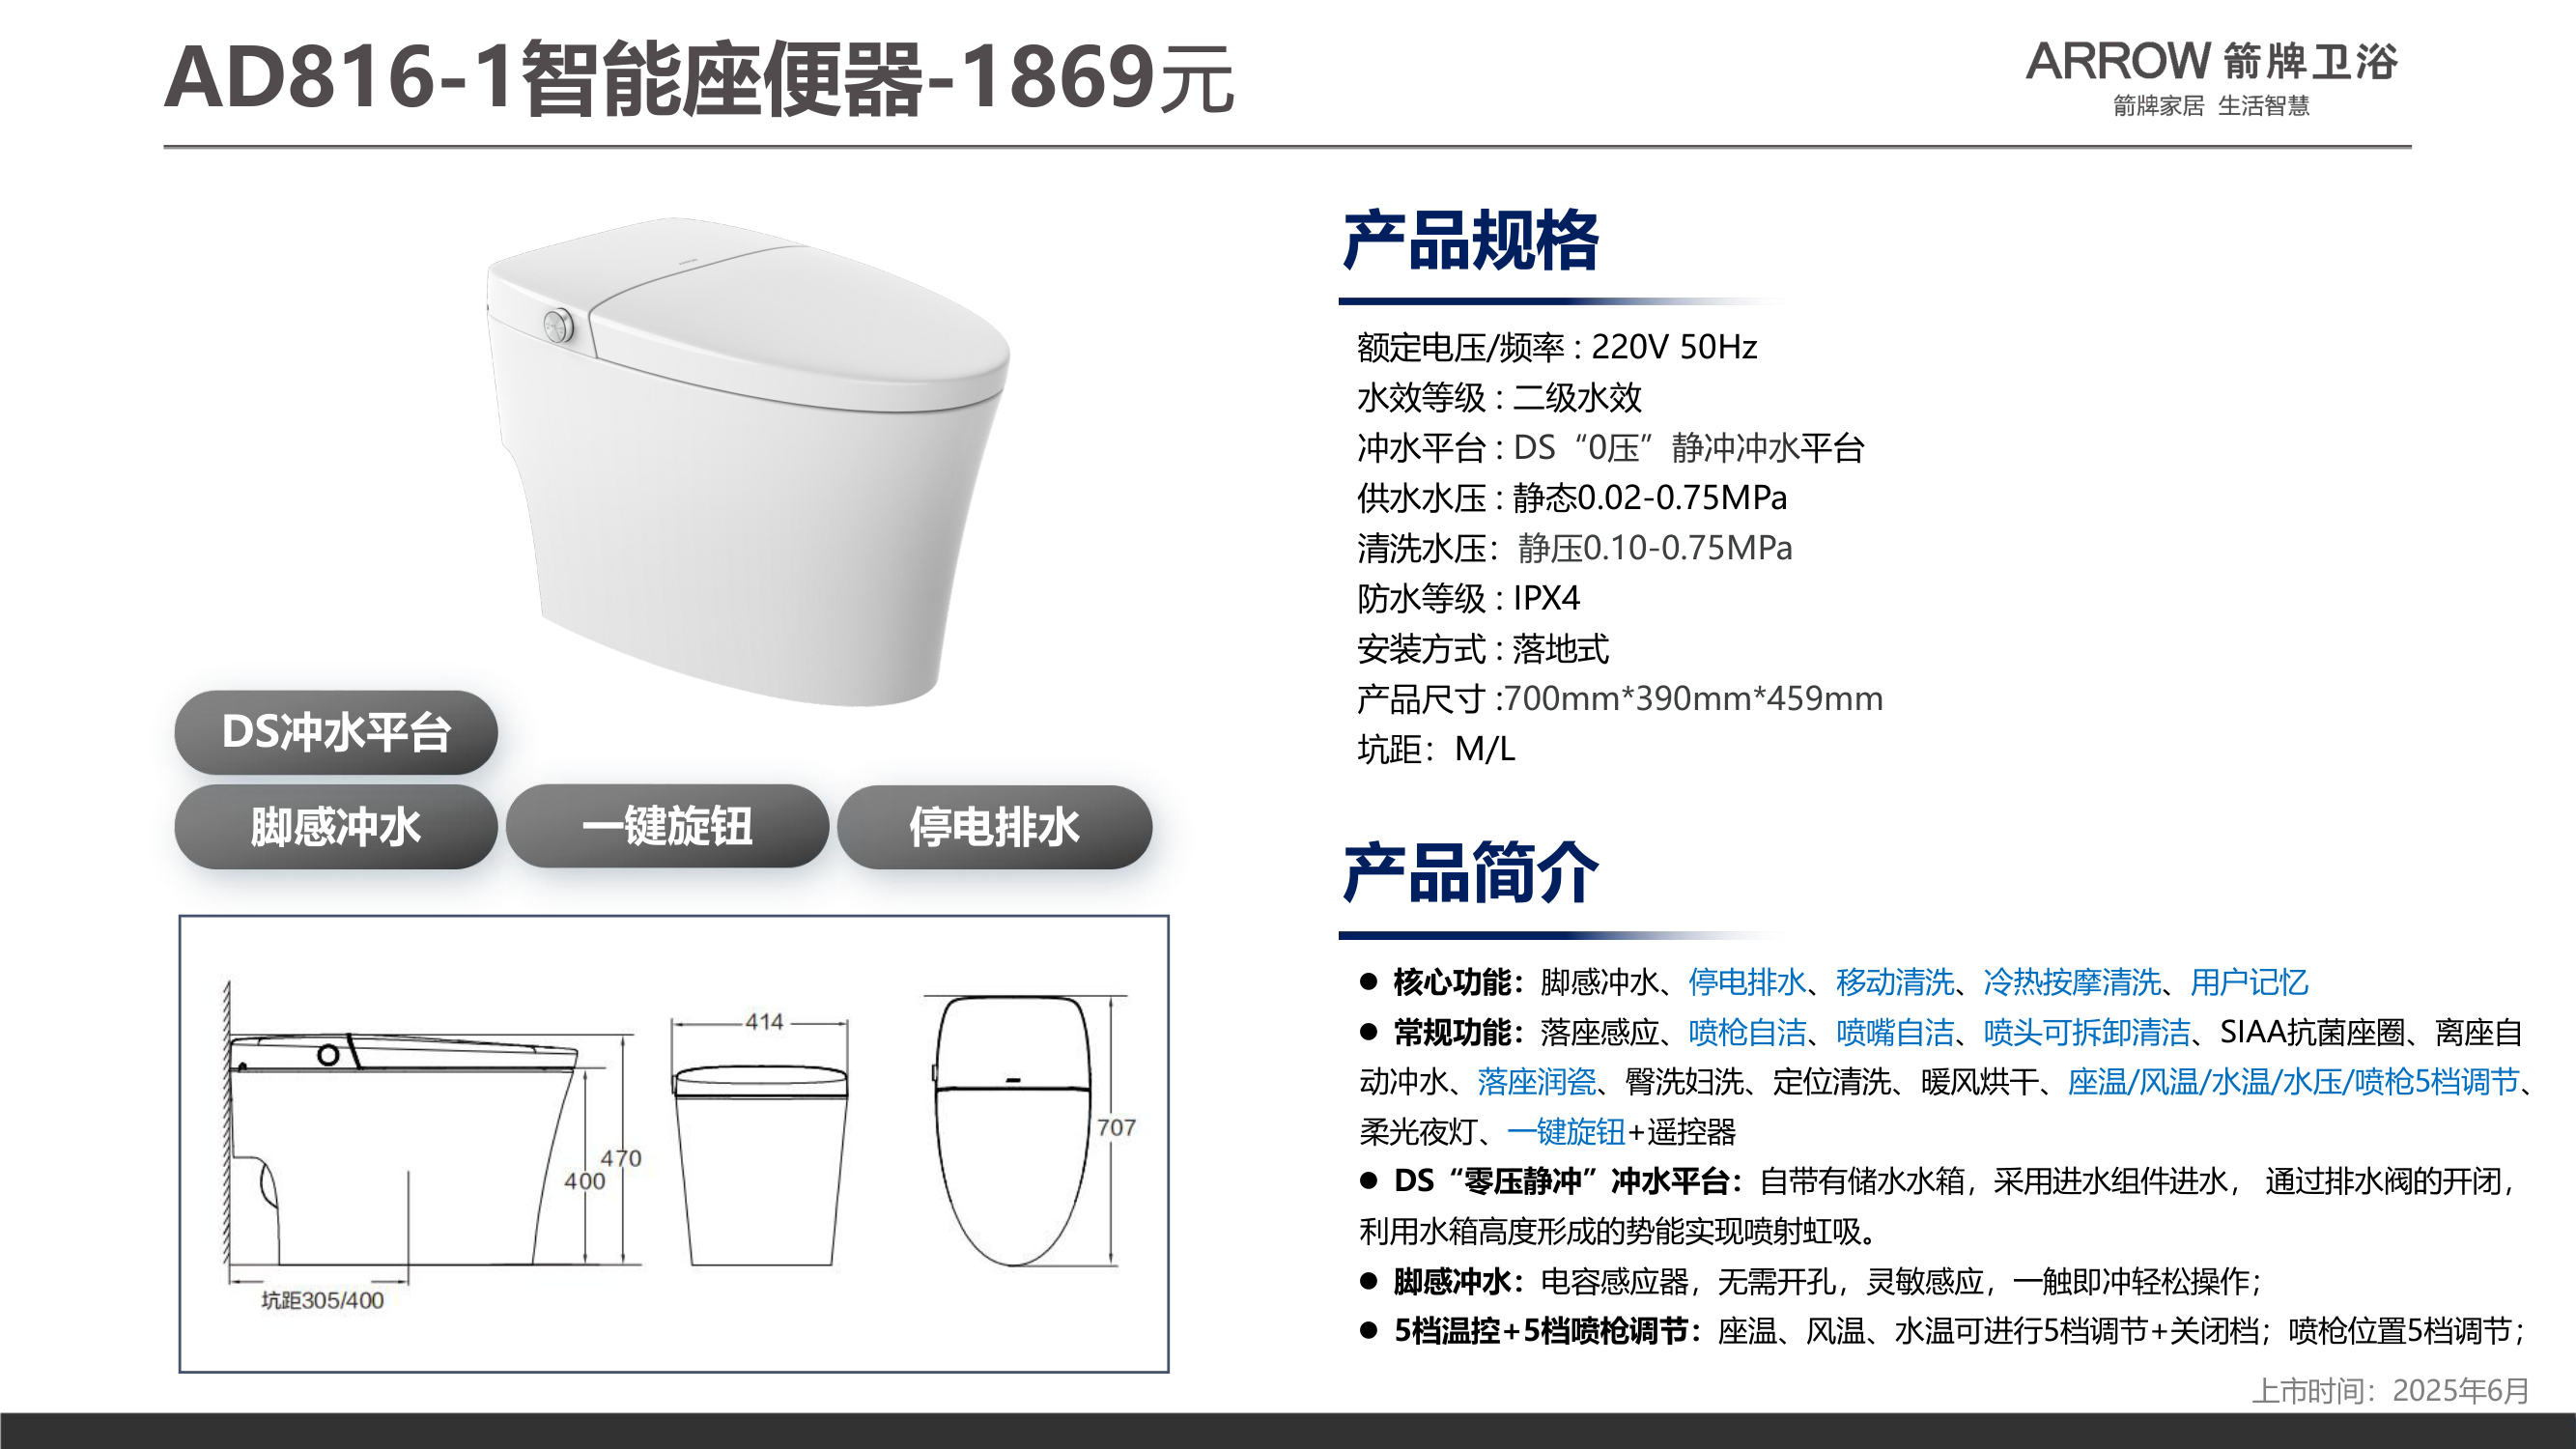

In [6]:
pages[0]

# Парсинг информации с карточек товаров

In [7]:
def run_vlm(images: list[Image], **chat_template_kwargs):
    
    enable_thinking = chat_template_kwargs.pop("enable_thinking", False)
    
    client = OpenAI(
        api_key="EMPTY",
        base_url="http://localhost:8000/v1",
    )

    template = {
        "products": [
            {
                "name": "string",
                "description": ["verbatim-string"],
                
                "brand": "verbatim-string",
                "manufacturer": "verbatim-string",
                
                "product_center": {
                    "x": "number",
                    "y": "number",
                },
                
                "price": {
                    "value": "number",
                    "currency": "currency",
                },
                
                "specifications": {
                    "length": {
                        "value": "number", 
                        "unit": "unit-code"
                    },
                    "width": {
                        "value": "number", 
                        "unit": "unit-code"
                    },
                    "height": {
                        "value": "number", 
                        "unit": "unit-code"
                    },
                    "weight": {
                        "value": "number", 
                        "unit": "unit-code"
                    },
                    "volume": {
                        "value": "number", 
                        "unit": "unit-code"
                    },
                    "square": {
                        "value": "number", 
                        "unit": "unit-code"
                    },
                    "other": ["verbatim-string"],
                },
                
                "sku": "verbatim-string",
            }
        ]
    }

    prompt = """
    Extract ONLY real product cards from the catalog page.

    A valid product card MUST contain ALL of the following:
    - SKU / article number
    - price with numeric value (NOT null)
    - at least one technical specification with numeric value (NOT null)

    If ANY of these are missing — do NOT include the product.
    If NO valid products exist on the page — return {"products": []}.

    RULES FOR PRODUCT NAME:
    - "name" MUST contain ONLY the generic product category/type
    (e.g., "Smartphone", "Toilet", "Ceramic tile", "Power drill")
    - The name should answer the question: "What KIND of object is this?"
    - NEVER use model codes, series names, alphanumeric identifiers,
    or catalog headings as the product name
    - Patterns like "N7-6", "X200 Pro", "ABC-123", "Model XYZ" are NOT names —
    they belong in "sku"
    - If the page heading looks like "<Letters><Numbers>" or "<Word><Number>",
    treat it as a model/SKU identifier, NOT as a product name
    - Infer the product type from the image and/or specifications if no
    explicit category label is present

    RULES FOR SKU:
    - "sku" MUST capture all model codes, series identifiers, article numbers,
    and catalog IDs found on the page
    - If the page heading is alphanumeric (e.g. "N7 6", "T7200"), put it in "sku"
    - Combine multiple identifiers with " / " separator

    Each "product_center" MUST satisfy:
    - normalized coordinates in range [0.0, 1.0]
    - x and y represent the center of the main product photo ONLY
    - coordinates are relative to full page width and height
    - (0,0) is top-left, (1,1) is bottom-right

    EXAMPLES OF CORRECT EXTRACTION:
    Page heading "N7 6", image shows a phone → name: "Smartphone", sku: "N7 6"
    Page heading "TB-2000", image shows a toilet → name: "Toilet", sku: "TB-2000"
    Page heading "ProDrill X5" → name: "Power drill", sku: "ProDrill X5"
    """


    def to_base64(image):
        buffered = BytesIO()
        image.save(buffered, format="PNG")
        img_bytes = buffered.getvalue()
        base64_string = base64.b64encode(img_bytes).decode("utf-8")
        return base64_string


    response = client.chat.completions.create(
        model="numind/NuExtract3",
        temperature=0.0,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/png;base64,{to_base64(image)}"},
                    }
                    for image in images
                ],
            }
        ],
        extra_body={
            "chat_template_kwargs": {
                "template": json.dumps(template, indent=4),
                "instructions": prompt,
                "enable_thinking": enable_thinking
            }
        }
    )

    return [response.choices[0].message.content]

In [8]:
vlm_results = run_vlm(pages, enable_thinking=True)
vlm_results = [json.loads(res) for res in vlm_results]

print(json.dumps(vlm_results, indent=4, ensure_ascii=False))

[
    {
        "products": [
            {
                "name": "智能座便器",
                "description": [
                    "核心功能: 脚感冲水、停电排水、移动清洗、冷热按摩清洗、用户记忆",
                    "常规功能: 落座感应、喷枪自洁、喷嘴自洁、喷头可拆卸清洁、SIAA抗菌座圈、离座自动冲水、落座润瓷、臀洗妇洗、定位清洗、暖风烘干、座温/风温/水温/水压/喷枪5档调节、柔光夜灯、一键旋钮+遥控器",
                    "DS“零压静冲”冲水平台: 自带有储水水箱, 采用进水组件进水, 通过排水阀的开闭, 利用水箱高度形成的势能实现喷射虹吸。",
                    "脚感冲水: 电容感应器, 无需开孔, 灵敏感应, 一触即冲轻松操作;",
                    "5档温控+5档喷枪调节: 座温、风温、水温可进行5档调节+关闭档; 喷枪位置5档调节;"
                ],
                "brand": "ARROW",
                "manufacturer": "箭牌家居",
                "product_center": {
                    "x": 0.5,
                    "y": 0.3
                },
                "price": {
                    "value": 1869,
                    "currency": "CNY"
                },
                "specifications": {
                    "length": {
                        "value": 470,
                        "unit": "mm"
                    },
            

# Перевод на русский извлеченной информации

In [9]:
def run_translator(products: list[dict], **chat_template_kwargs):
    
    enable_thinking = chat_template_kwargs.pop("enable_thinking", False)

    client = OpenAI(
        api_key="EMPTY",
        base_url="http://localhost:8000/v1",
    )

    template = {
        "products": [
            {
                "name": "string",
                "description": ["string"],

                "brand": "string",
                "manufacturer": "string",

                "product_center": {
                    "x": "number",
                    "y": "number",
                },
                
                "price": {
                    "value": "number",
                    "currency": "currency",
                },

                "specifications": {
                    "length": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "width": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "height": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "weight": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "volume": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "square": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "other": ["string"],
                },
                
                "sku": "string",
            }
        ]
    }

    prompt = """
    Translate the product catalog JSON to Russian.

    TRANSLATION RULES:
    - Translate ALL text to natural Russian
    - Use professional Russian technical terminology
    - Translate product names as commercial product titles used in Russian catalogs
    - Avoid literal word-by-word translation
    - Use concise catalog language

    SKU / BRAND RULES:
    - Preserve SKU exactly without translation
    - Preserve model codes exactly
    - Preserve brand names exactly
    - Do not translate brand names
    - Do not translate manufacturer names if they are company names

    STYLE RULES:
    - Use grammatically correct Russian
    - Avoid awkward literal translations
    - Prefer established Russian technical terms
    """

    response = client.chat.completions.create(
        model="numind/NuExtract3",
        temperature=0.0,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": json.dumps(product, indent=4),
                    }
                    for product in products
                ],
            }
        ],
        extra_body={
            "chat_template_kwargs": {
                "template": json.dumps(template, indent=4),
                "instructions": prompt,
                "enable_thinking": enable_thinking
            }
        }
    )

    return [response.choices[0].message.content]

In [10]:
translated_results = run_translator(vlm_results, enable_thinking=True)
translated_results = [json.loads(res) for res in translated_results]

print(json.dumps(translated_results, indent=4, ensure_ascii=False))

[
    {
        "products": [
            {
                "name": "Умная мебель",
                "description": [
                    "Основные функции: умное смывание по нажатию, самосмывание при остановке, очистка при движении, охлаждающее массажное смывание, запоминание пользователя",
                    "Стандартные функции: датчик присутствия при посадке, самоочистка сопла, съемная очистка сопла, съемное сиденье для очистки, SIAA антибактериальное сиденье, автоматическое смывание при удалении, смазка при посадке, очистка подкладки, целевая очистка, сушка горячим воздухом, 5-ступенчатая регулировка температуры сиденья, температуры воздуха, температуры воды, давления воды и сопла, мягкая ночная лампа, однокнопочный переключатель + пульт дистанционного управления",
                    "Платформа смывания DS \"Zero-Pressure Quiet Flush\": встроенный резервуар для воды, использование комплектующих для подачи воды, через открытие/закрытие клапана слива, реализация силы всасывания стр

# Определение изображения товара

In [11]:
class PreprocessProfile(Enum):
    """Профили под разные типы каталогов."""
    LIGHT_CATALOG   = "light"   # белый/светлый фон, типичный каталог
    DARK_CATALOG    = "dark"    # тёмный фон
    LOW_CONTRAST    = "low"     # выцветшие сканы
    DENSE_GRID      = "dense"   # много мелких карточек


def pil_to_cv2(img: Image.Image) -> np.ndarray:
    return cv2.cvtColor(np.array(img.convert("RGB")), cv2.COLOR_RGB2BGR)


def cv2_to_pil(arr: np.ndarray) -> Image.Image:
    return Image.fromarray(cv2.cvtColor(arr, cv2.COLOR_BGR2RGB))


def apply_clahe(img_bgr: np.ndarray, clip: float = 2.0, tile: int = 8) -> np.ndarray:

    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
    l_eq = clahe.apply(l)

    merged = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)


def apply_unsharp_mask(
    img_bgr: np.ndarray,
    blur_ksize: int = 0,       # 0 = авто по sigma
    sigma: float = 1.5,
    strength: float = 1.5,     # коэффициент усиления краёв
    threshold: int = 5,        # порог: игнорируем слишком слабые края
) -> np.ndarray:

    blurred = cv2.GaussianBlur(img_bgr, (blur_ksize, blur_ksize), sigma)
    diff = cv2.subtract(img_bgr.astype(np.int16), blurred.astype(np.int16))

    mask = (np.abs(diff) > threshold).astype(np.float32)
    sharpened = img_bgr.astype(np.float32) + strength * diff * mask

    return np.clip(sharpened, 0, 255).astype(np.uint8)


def apply_edge_overlay(
    img_bgr: np.ndarray,
    low: int = 30,
    high: int = 100,
    weight: float = 0.25,
) -> np.ndarray:

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, low, high)
    edges_bgr = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR).astype(np.float32)

    blended = img_bgr.astype(np.float32) * (1 - weight) + edges_bgr * weight
    return np.clip(blended, 0, 255).astype(np.uint8)


def apply_gamma(img_bgr: np.ndarray, gamma: float = 1.3) -> np.ndarray:

    lut = np.array([
        min(255, int((i / 255.0) ** (1.0 / gamma) * 255))
        for i in range(256)
    ], dtype=np.uint8)
    return cv2.LUT(img_bgr, lut)


def apply_bilateral(
    img_bgr: np.ndarray,
    d: int = 9,
    sigma_color: float = 75,
    sigma_space: float = 75,
) -> np.ndarray:
    return cv2.bilateralFilter(img_bgr, d, sigma_color, sigma_space)


def apply_denoising(img_bgr: np.ndarray, h: float = 8.0) -> np.ndarray:
    return cv2.fastNlMeansDenoisingColored(img_bgr, None, h, h, 7, 21)


def apply_morphological_close(
    img_bgr: np.ndarray,
    ksize: int = 3,
) -> np.ndarray:
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, ksize))
    return cv2.morphologyEx(img_bgr, cv2.MORPH_CLOSE, kernel)


def auto_detect_profile(img: Image.Image) -> PreprocessProfile:
    """Анализирует гистограмму и выбирает профиль автоматически."""
    arr = np.array(img.convert("L"), dtype=np.float32)

    mean       = arr.mean()
    std        = arr.std()
    dark_ratio = (arr < 60).mean()   # доля тёмных пикселей

    if dark_ratio > 0.4:
        return PreprocessProfile.DARK_CATALOG
    if std < 35:
        return PreprocessProfile.LOW_CONTRAST
    if mean > 200 and std < 55:
        return PreprocessProfile.DENSE_GRID

    return PreprocessProfile.LIGHT_CATALOG
    
def preprocess_for_detection(
    img: Image.Image,
    profile: PreprocessProfile | None = None,
) -> Image.Image:

    if profile is None:
        profile = auto_detect_profile(img)
    
    bgr = pil_to_cv2(img)

    if profile == PreprocessProfile.LIGHT_CATALOG:
        bgr = apply_clahe(bgr, clip=2.0)
        bgr = apply_unsharp_mask(bgr, sigma=1.5, strength=1.4)
        bgr = apply_edge_overlay(bgr, low=25, high=80, weight=0.2)

    elif profile == PreprocessProfile.DARK_CATALOG:
        bgr = apply_gamma(bgr, gamma=1.4)
        bgr = apply_clahe(bgr, clip=3.0)
        bgr = apply_unsharp_mask(bgr, sigma=1.0, strength=1.2)

    elif profile == PreprocessProfile.LOW_CONTRAST:
        bgr = apply_bilateral(bgr)
        bgr = apply_clahe(bgr, clip=4.0, tile=4)
        bgr = apply_unsharp_mask(bgr, sigma=2.0, strength=1.8)
        bgr = apply_edge_overlay(bgr, low=15, high=60, weight=0.15)

    elif profile == PreprocessProfile.DENSE_GRID:
        bgr = apply_bilateral(bgr, sigma_color=50, sigma_space=50)
        bgr = apply_clahe(bgr, clip=1.5)
        bgr = apply_unsharp_mask(bgr, sigma=0.8, strength=2.0)
        bgr = apply_morphological_close(bgr, ksize=2)
        bgr = apply_edge_overlay(bgr, low=20, high=70, weight=0.3)

    return cv2_to_pil(bgr)

In [12]:
def run_layout_detector(images: list[Image]):

    inputs = detector_processor(
        images=images, 
        return_tensors="pt"
    ).to(detector.device)

    with torch.inference_mode():
        outputs = detector(**inputs)

    detector_results = detector_processor.post_process_object_detection(
        outputs, 
        threshold=0.3,
        target_sizes=[img.size[::-1] for img in images]
    )

    batch_results = []
    for result in detector_results:
        boxes = result['boxes']
        label_ids = result['labels']

        images_bboxes = [
            bbox.tolist()
            for bbox, label_id in zip(boxes, label_ids)
            if detector.config.id2label[label_id.item()] == 'image'
        ]
        batch_results.append(images_bboxes)
    
    return batch_results

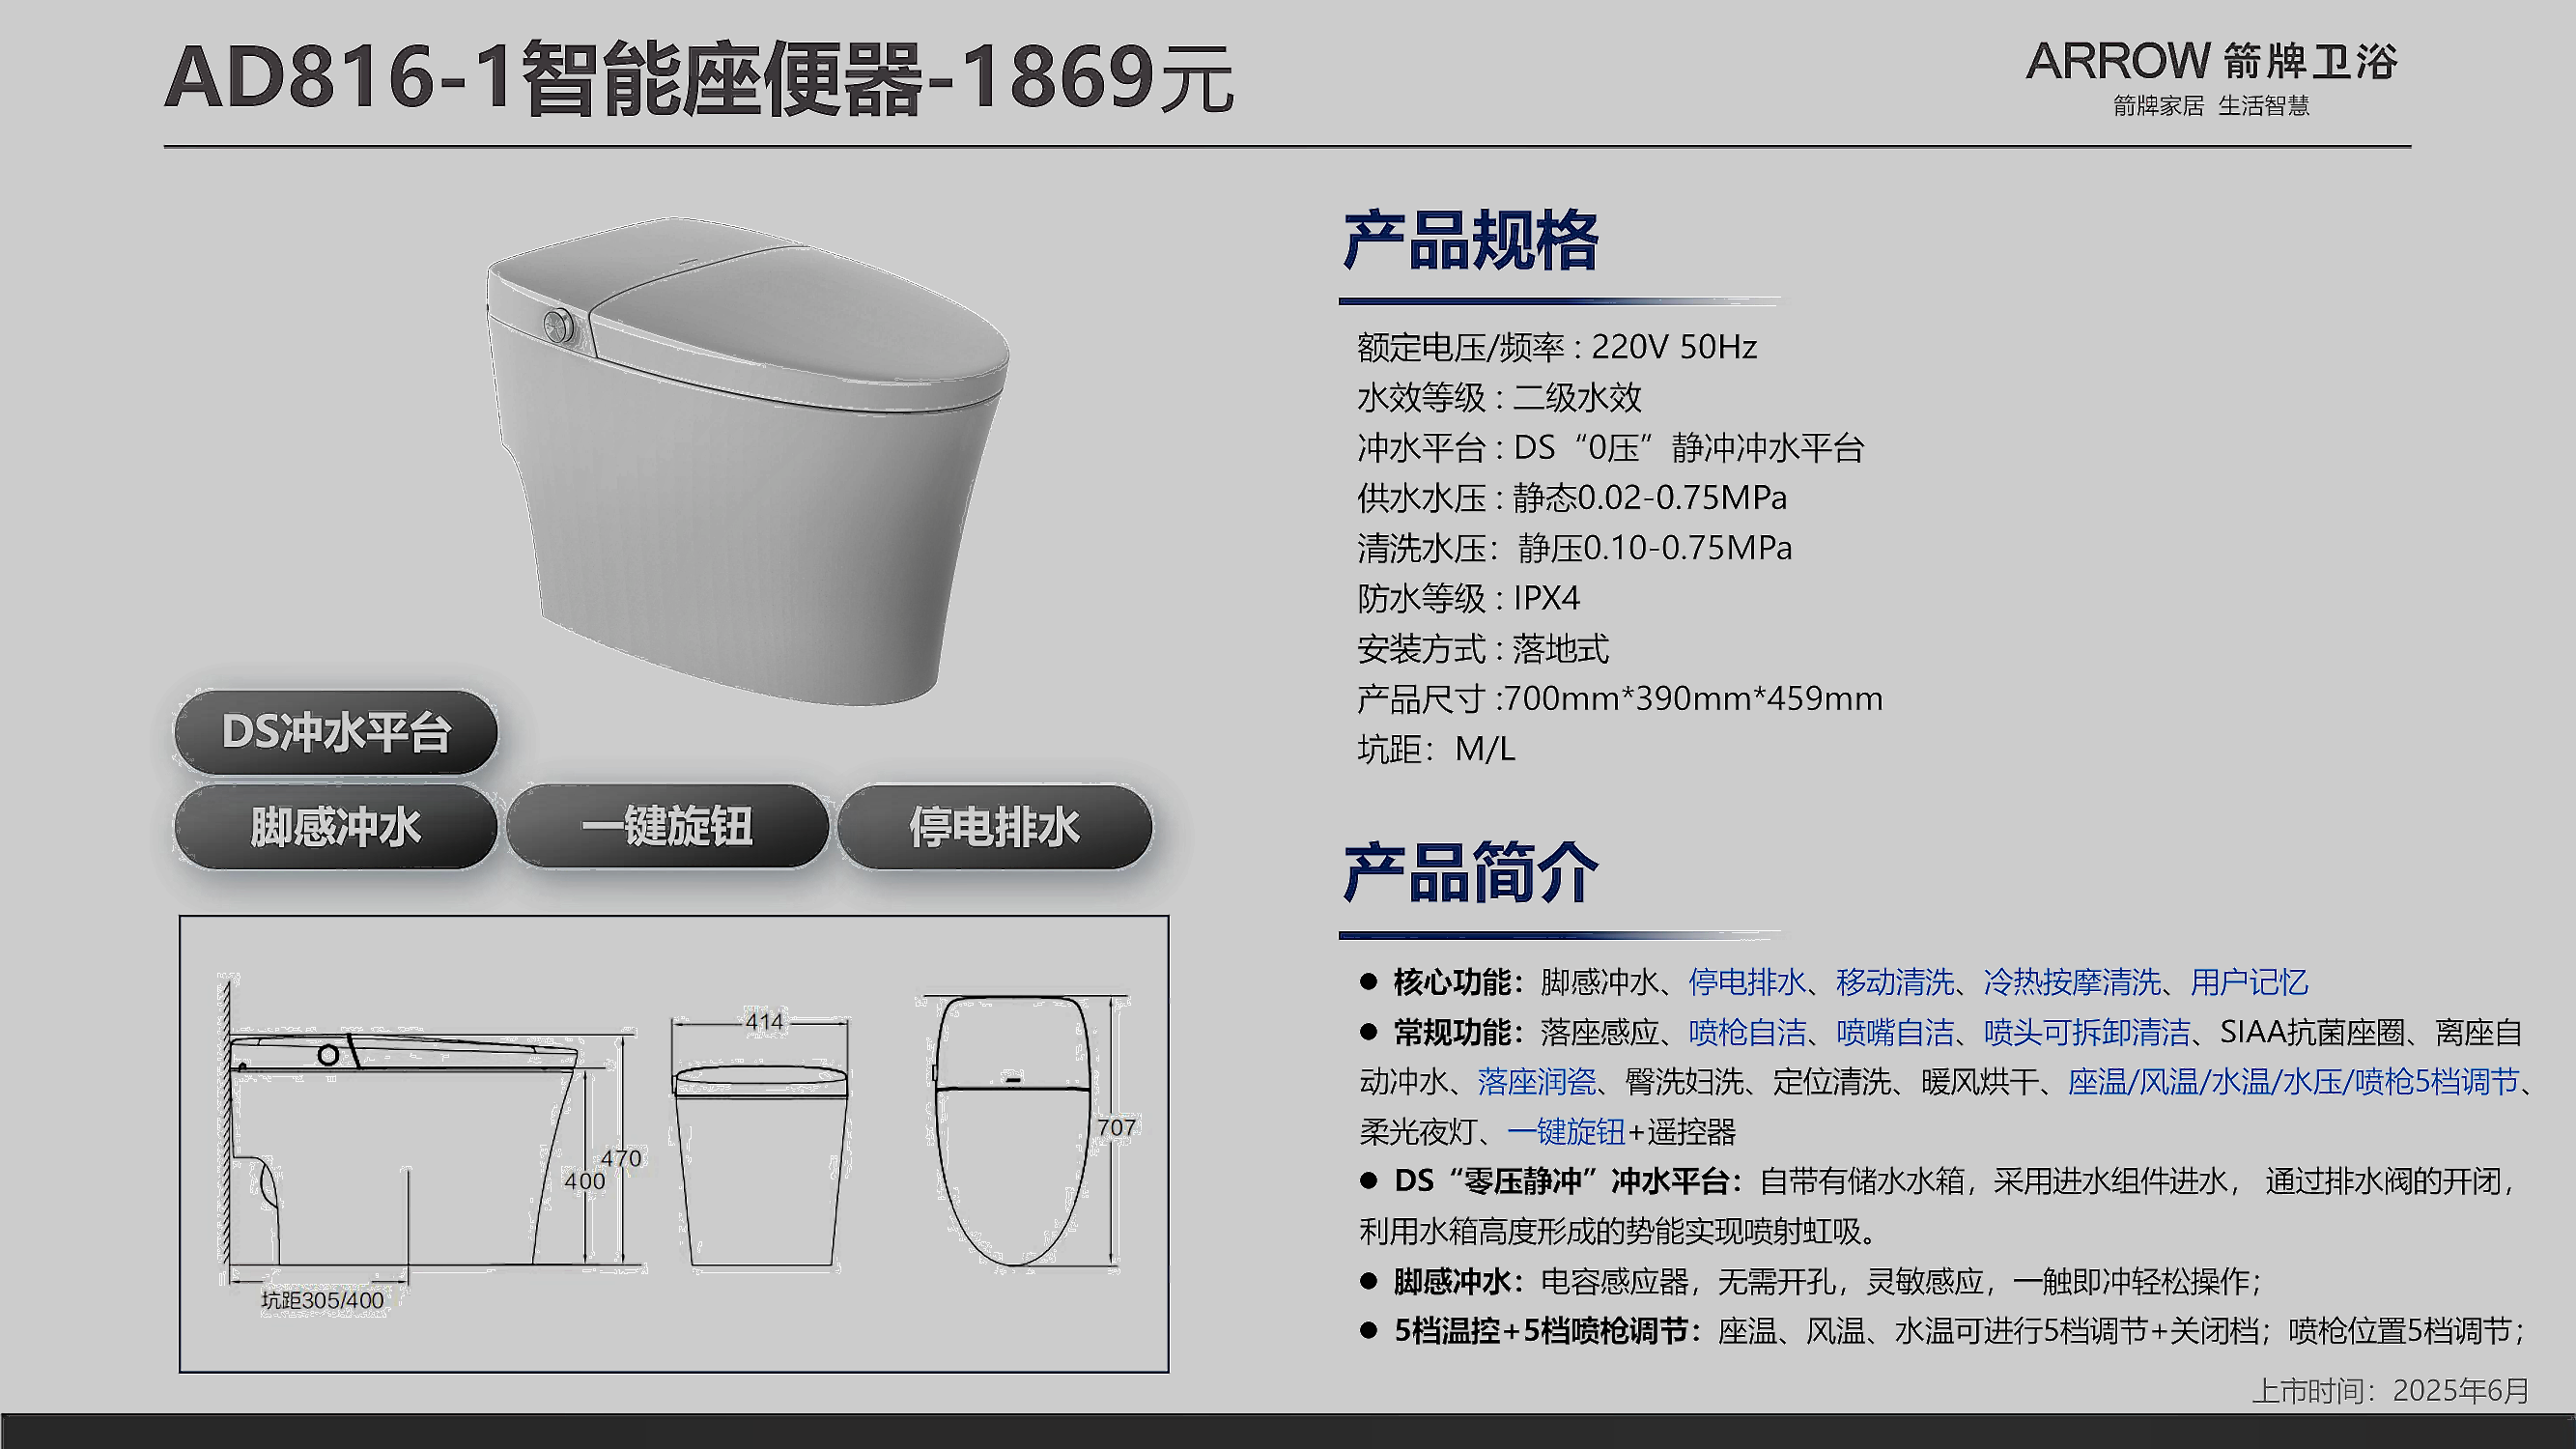

In [14]:
preprocess_for_detection(pages[0])

In [15]:
preprocessed_pages = [preprocess_for_detection(page) for page in pages]

detector_results = run_layout_detector(preprocessed_pages)
detector_results

[[[483.01812744140625, 215.6071319580078, 1044.0361328125, 742.7915649414062],
  [171.16432189941406,
   220.57284545898438,
   1210.2508544921875,
   1372.882568359375],
  [217.57357788085938,
   1004.4075927734375,
   671.6436767578125,
   1352.299560546875],
  [694.4226684570312,
   1033.3177490234375,
   886.6195068359375,
   1321.4739990234375],
  [949.411865234375, 1024.616455078125, 1184.0313720703125, 1319.703125]]]

In [16]:
def calculate_products_images(pages, vlm_results, detector_results, output_dir):
    

    def _normalize_name(name: str) -> str:
        return (
            name
            .replace(" ", "_")
            .replace("/", "_")
            .replace("\\", "_")
            .replace("-", "_")
        ) 


    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    results: list[tuple[dict, str]] = []

    for page, vlm_res, det_res in zip(pages, vlm_results, detector_results):

        width, height = page.size

        products = vlm_res["products"]
        if len(products) == 0:
            continue

        if len(det_res) == 0:
            full_bbox = (0, 0, width, height)

            for product in products:

                product_name = product["name"]
                product_sku = product["sku"]
                product_name = _normalize_name(product_name)

                img_path = str(output_dir / f"{product_name}_{product_sku}.png")

                cropped = page.crop(full_bbox)
                cropped.save(img_path)

                results.append((product, img_path))

            continue

        det_bboxes = np.asarray(det_res, dtype=np.float32)

        det_bbox_centers = np.column_stack([
            (det_bboxes[:, 0] + det_bboxes[:, 2]) / 2,
            (det_bboxes[:, 1] + det_bboxes[:, 3]) / 2,
        ])
        vlm_bbox_centers = np.array(
            [
                [
                    p["product_center"]["x"] * width,
                    p["product_center"]["y"] * height,
                ]
                for p in products
            ], 
            dtype=np.float32
        )

        tree = cKDTree(det_bbox_centers)
        indices = tree.query(vlm_bbox_centers, k=1)[1]

        for product, bbox_idx in zip(products, indices):

            bbox = det_bboxes[bbox_idx]

            product_name = product["name"]
            product_sku = product["sku"]
            product_name = _normalize_name(product_name)

            img_path = str(output_dir / f"{product_name}_{product_sku}.png")

            cropped = page.crop(tuple(map(int, bbox)))
            cropped.save(img_path)

            results.append((product, img_path))

    return results

In [17]:
products_with_image = calculate_products_images(
    pages,
    translated_results,
    detector_results,
    output_dir = "../data/products"
)

In [18]:
products_with_image

[({'name': 'Умная мебель',
   'description': ['Основные функции: умное смывание по нажатию, самосмывание при остановке, очистка при движении, охлаждающее массажное смывание, запоминание пользователя',
    'Стандартные функции: датчик присутствия при посадке, самоочистка сопла, съемная очистка сопла, съемное сиденье для очистки, SIAA антибактериальное сиденье, автоматическое смывание при удалении, смазка при посадке, очистка подкладки, целевая очистка, сушка горячим воздухом, 5-ступенчатая регулировка температуры сиденья, температуры воздуха, температуры воды, давления воды и сопла, мягкая ночная лампа, однокнопочный переключатель + пульт дистанционного управления',
    'Платформа смывания DS "Zero-Pressure Quiet Flush": встроенный резервуар для воды, использование комплектующих для подачи воды, через открытие/закрытие клапана слива, реализация силы всасывания струи за счет потенциальной энергии, образованной высотой резервуара',
    'Капакторный датчик: без необходимости сверления, чув

# Конвертирование в номенклатуру

In [19]:
COLUMN_MAPPING = {
    "name":           "A",
    "sku":            "D",

    "weight_unit":    "F",
    "weight_flag":    "H",
    "weight_value":   "J",

    "length_unit":    "T",
    "length_flag":    "V",
    "length_value":   "X",

    "description":    "AH",

    "brand":          "AD",
    "manufacturer":   "AI",

    "image_path":     "AN",

    "volume_unit":    "AP",
    "volume_flag":    "AR",
    "volume_value":   "AT",

    "square_unit":    "AV",
    "square_flag":    "AZ",
    "square_value":   "BB",

    "origin_country": "CK",
}


def _product_to_row(product: dict, image_path: str) -> dict:
    specs = product.get("specifications") or {}

    def _val(name):
        return (specs.get(name) or {}).get("value")

    def _unit(name):
        return (specs.get(name) or {}).get("unit")
        
    def _flag(name):
        return bool(_val(name))

    name = product.get("name") or ""

    return {
        "name":           name,
        "sku":            product.get("sku"),
        "weight_unit":    _unit("weight"),
        "weight_flag":    _flag("weight"),
        "weight_value":   _val("weight"),
        "length_unit":    _unit("length"),
        "length_flag":    _flag("length"),
        "length_value":   _val("length"),
        "description":    "\n".join(product.get("description") or []),
        "brand":          product.get("brand"),
        "manufacturer":   product.get("manufacturer"),
        "image_path":     image_path,
        "volume_unit":    _unit("volume"),
        "volume_flag":    _flag("volume"),
        "volume_value":   _val("volume"),
        "square_unit":    _unit("square"),
        "square_flag":    _flag("square"),
        "square_value":   _val("square"),
        "origin_country": None,
    }


def _write_row(sheet, row: int, row_data: dict) -> None:
    for col_key, value in row_data.items():
        col = COLUMN_MAPPING.get(col_key)
        if col is not None:
            sheet[f"{col}{row}"] = value


def export_to_excel(products: list[tuple[dict, str]], template_path: str, output_path: str) -> None:
    
    workbook = load_workbook(template_path)
    sheet    = workbook.active
    row      = sheet.max_row + 1

    for product, img_path in products:
        _write_row(sheet, row, _product_to_row(product, img_path))
        row += 1

    workbook.save(output_path)

In [ ]:
export_to_excel(
    products_with_image,
    template_path="../data/nomenclature/template.xlsx",
    output_path="../data/nomenclature/2026箭牌卫浴产品-5-9.xlsx",
)